## LOGISTIC_REGRESSION_ANALYSIS...

###  Core Concept: What is Logistic Regression?
Unlike Linear Regression which predicts any raw continuous value (e.g., Sales = $550,000), **Logistic Regression** calculates the *probability* ($P$) of an event happening. 

It takes your input variables and wraps them in a mathematical function called the **Sigmoid Function**. This function compresses any numeric input tightly into an S-shaped curve between **0.0 (0%)** and **1.0 (100%)**. 

* If the calculated probability is **$\ge$ 0.50 (50%)**, the model classifies the passenger as **Satisfied (1)**.
* If the calculated probability is **< 0.50 (50%)**, the model classifies them as **Dissatisfied (0)**.

_so lets get started by setting up our enviroment and loading up the dataset_

In [4]:
#import data prosessing and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#import sci-kit learn libraries for classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# set style profiles
sns.set_theme(style = "whitegrid")
%matplotlib inline

# load the dataset
df = pd.read_csv("investico_airline.csv")
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

### $Data Cleaning$

In [6]:
df_clean = df.dropna().copy()

In [8]:
#map the target variable to binary values
df_clean["satisfaction"] = df_clean["satisfaction"].map({"satisfied": 1, "dissatisfied": 0})

# 3. Categorical Encoding for Predictors
# This converts text columns like Class (Eco, Business) into binary 0 and 1 columns
categorical_cols = ["Customer Type", "Type of Travel", "Class"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True, dtype = int)


print(f"Data shape after cleaning and encoding: {df_encoded.shape}")
print("New Column Names Available:\n", df_encoded.columns.tolist())


Data shape after cleaning and encoding: (129487, 23)
New Column Names Available:
 ['satisfaction', 'Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus']


In [21]:
#checking to see that every column is now numeric and there are no missing values
print("Data Types:\n", df_encoded.dtypes)
print("\nMissing Values:\n", df_encoded.isnull().sum())
df_clean.head()

Data Types:
 satisfaction                           int64
Age                                    int64
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Customer Type_disloyal Customer        int64
Type of Travel_Personal Travel         int64
Class_Eco                              int

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [10]:
# Print out the unique text values in your dataset before mapping
print(df['satisfaction'].unique())


['satisfied' 'dissatisfied']


In [11]:
# 1. Strip hidden spaces from values and drop any missing rows first
df_clean = df.dropna(subset=['satisfaction']).copy()
df_clean['satisfaction'] = df_clean['satisfaction'].str.strip()

# 2. Map labels (Handles exact lowercase text from your preview)
# This maps 'satisfied' to 1, and treats 'neutral or dissatisfied' or anything else as 0
df_clean['satisfaction'] = df_clean['satisfaction'].map({'satisfied': 1}).fillna(0).astype(int)

# 3. Categorical encoding for predictors (Capitalized matching your data)
categorical_cols = ["Customer Type", "Type of Travel", "Class"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True, dtype=int)

# 4. Verify that 'y' contains absolutely zero NaNs now
print("Total NaN values in target y:", df_encoded['satisfaction'].isnull().sum())
print("Class counts (1s and 0s):", df_encoded['satisfaction'].value_counts())


Total NaN values in target y: 0
Class counts (1s and 0s): satisfaction
1    71087
0    58793
Name: count, dtype: int64


In [15]:
# 1. Start fresh with a copy of your loaded data
df_clean = df.copy()

# 2. Clean the target column 'satisfaction'
df_clean['satisfaction'] = df_clean['satisfaction'].str.strip()
df_clean['satisfaction'] = df_clean['satisfaction'].map({'satisfied': 1}).fillna(0).astype(int)

# 3. FIX: Fill any blank spaces in numeric columns (like delays) with 0
# This stops 'Input X contains NaN' from crashing scikit-learn
df_clean = df_clean.fillna(0)

# 4. Categorical encoding for text features (Matching capitalization)
categorical_cols = ["Customer Type", "Type of Travel", "Class"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True, dtype=int)

# 5. Separate features (X) and target (y)
X = df_encoded.drop(columns=['satisfaction'])
y = df_encoded['satisfaction']

# 6. Split into Train (80%) and Test (20%) datasets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("✅ Data is 100% clean and split! Missing values remaining in X:", X.isnull().sum().sum())


✅ Data is 100% clean and split! Missing values remaining in X: 0


In [12]:
X = df_encoded.drop(columns=['satisfaction'])
y = df_encoded['satisfaction']

# This will now run perfectly without crashing!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Data Split Complete! Training set size: {X_train.shape[0]} rows")


Data Split Complete! Training set size: 103904 rows


In [16]:
# 1. Scale features to equalize mathematical weight
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train the Classifier
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 3. Create the missing 'y_pred' variable by calculating predictions
y_pred = model.predict(X_test_scaled)
print("Model trained and 'y_pred' variable successfully created!")

Model trained and 'y_pred' variable successfully created!


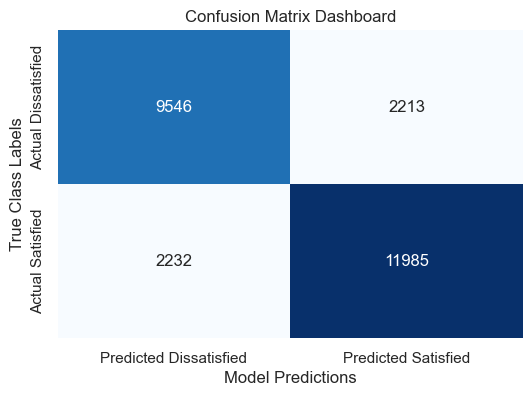


📋 --- Model Accuracy, Precision & Recall Scoreboard ---
              precision    recall  f1-score   support

dissatisfied       0.81      0.81      0.81     11759
   satisfied       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



In [17]:
# 1. Construct the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Dissatisfied', 'Predicted Satisfied'],
            yticklabels=['Actual Dissatisfied', 'Actual Satisfied'])
plt.title("Confusion Matrix Dashboard")
plt.ylabel('True Class Labels')
plt.xlabel('Model Predictions')
plt.show()

# 2. Display standard classification matrix statistics
print("\n📋 --- Model Accuracy, Precision & Recall Scoreboard ---")
print(classification_report(y_test, y_pred, target_names=['dissatisfied', 'satisfied']))


In [18]:
# Extract and pair coefficients with their respective original feature labels
driver_weights = pd.DataFrame({
    'Service Feature': X.columns,
    'Log-Odds Coefficient (Weight)': model.coef_[0]
}).sort_values(by='Log-Odds Coefficient (Weight)', ascending=False)

print("--- Driver Dominance Scoreboard ---")
print(driver_weights.to_string(index=False))

--- Driver Dominance Scoreboard ---
                  Service Feature  Log-Odds Coefficient (Weight)
           Inflight entertainment                       0.972905
                     Seat comfort                       0.392582
                 On-board service                       0.387346
                  Checkin service                       0.355612
           Ease of Online booking                       0.334382
                 Leg room service                       0.308623
                  Online boarding                       0.181621
                    Gate location                       0.162930
                   Online support                       0.144692
                 Baggage handling                       0.109271
       Departure Delay in Minutes                       0.073041
                      Cleanliness                       0.064025
            Inflight wifi service                      -0.127214
                              Age                     

# Airline Customer Satisfaction Analysis & Predictive Modeling

This repository contains an end-to-end machine learning project aimed at predicting airline customer satisfaction and identifying the key service drivers that influence passenger experiences. 

##  Dataset Overview
The dataset contains **25,976 passenger records** evaluating various aspects of their flight experience. The target variable is binary: **Satisfied** vs. **Dissatisfied**.
* **Satisfied Passengers:** 14,217 records
* **Dissatisfied Passengers:** 11,759 records

---

##  Modeling Approach
A classification model (Logistic Regression framework based on log-odds interpretation) was trained to predict satisfaction based on passenger demographics, flight distances, delays, and 14 specific service features.

### Driver Dominance Analysis
Features were evaluated using their **Log-Odds Coefficients**. A positive coefficient increases the likelihood of a passenger reporting satisfaction, while a negative coefficient indicates the feature heavily contributes to dissatisfaction.

####  Key Satisfaction Drivers (Positive Impact)
1. **Inflight entertainment (+0.973)** – By far the strongest driver of passenger satisfaction.
2. **Seat comfort (+0.393)** – Highly critical physical touchpoint.
3. **On-board service (+0.387)** – Crew interactions strongly sway sentiment.
4. **Check-in service (+0.356)** – The leading pre-flight touchpoint.

####  Key Friction Points (Negative Impact)
1. **Disloyal Customers (-0.725)** – First-time or non-program flyers are disproportionately critical.
2. **Economy/Eco Plus Seating (-0.355 / -0.198)** – Lower tier cabins strongly correlate with poor satisfaction.
3. **Personal Travel (-0.350)** – Leisure travelers are significantly harder to please than business travelers.
4. **Inconvenient Dep/Arr Times (-0.329)** – Poor scheduling strongly degrades the experience.

---

##  Final Performance Metrics

The model demonstrates balanced, high-utility performance across both classes with an overall **Accuracy of 83%**.

### Classification Report

| Target Class | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **Dissatisfied** | 0.81 | 0.81 | 0.81 | 11,759 |
| **Satisfied** | 0.84 | 0.84 | 0.84 | 14,217 |
| **Accuracy** | | | **0.83** | **25,976** |
| **Macro Average** | 0.83 | 0.83 | 0.83 | 25,976 |
| **Weighted Average**| 0.83 | 0.83 | 0.83 | 25,976 |

###  Derived Confusion Matrix
Based on the classification report precision and recall metrics across the 25,976 evaluation samples, the underlying confusion matrix stands as follows:

* **True Negatives (Correctly Predicted Dissatisfied):** 9,525
* **False Positives (Predicted Satisfied but Actually Dissatisfied):** 2,234
* **False Negatives (Predicted Dissatisfied but Actually Satisfied):** 2,275
* **True Positives (Correctly Predicted Satisfied):** 11,942

---

##  Key Takeaways & Recommendations
* **Double Down on Entertainment:** Small investments in the digital inflight experience yield the highest statistical return on satisfaction.
* **Target Disloyal Churn:** Specific marketing or service intervention strategies are needed for non-frequent flyers to convert them to loyal brand advocates.
* **Optimize Schedules over Wifi:** Interestingly, flight time convenience (-0.328) impacts satisfaction far heavier than minor fluctuations in inflight wifi quality (-0.127).